### 📊 CodeCritic State Transition Log Analysis — FSM Execution & Performance Breakdown

This notebook performs exploratory data analysis (EDA) on the **`state_transition_log`** table from a CodeCritic execution session. It reconstructs FSM execution paths, visualizes transition behavior across subsystems, and highlights performance and stability patterns in the system's state machine.

#### 🔍 Overview

* **Transition Timeline**
  Gantt-style visualizations showing when and how different FSM layers (Controller, System, State, Agent) are active.

* **Transition Reason Distribution**
  Countplots that break down why transitions occur — e.g., `INITIALIZATION`, `EVALUATING`, `SUCCESSFUL`.

* **Step Analysis**

  * Total steps per FSM type to understand subsystem load
  * Distribution of transitions across execution depth

* **Latency Breakdown**

  * Aggregated latency by provider type
  * Comparative bar charts of time spent across FSM components

* **Transition Frequency Matrix**
  Heatmap of `from_state → to_state` transitions to reveal common and rare paths through the FSM.

* **Graphical FSM Trace**

  * Grid-based graph view of linear transition flow with file context and step metadata
  * Annotated edge decisions and clear row-level structure

#### 🎯 Goal

The goal of this notebook is to **analyze the flow and performance of FSM transitions** in CodeCritic. It helps identify:

* Execution bottlenecks
* High-latency segments
* Transition loop patterns
* Run-to-run consistency issues

This analysis informs **performance tuning, fault tracing**, and **FSM design improvements** in the CodeCritic platform.


### 🛠️ Project Root Setup + Database Reset and Seeding

This cell resets the entire database schema and seeds it with initial data. It is typically used in local development or test environments before running sessions.

#### 🧠 What this code does:

1. **Sets the working directory** to the project root (`C:\Repos\codecritic`) so all relative imports and paths resolve correctly.
2. **Imports all seeders** from `app.db.seeders` to populate the database with provider and configuration records.
3. **Drops and recreates** all tables using SQLAlchemy’s `Base.metadata.drop_all()` and `create_all()` for a clean start.
4. **Runs all seeders** in a single transaction using `Session(bind=engine)` to insert:
   - Prompts and prompt providers
   - Tools, scores, and agent engines
   - Agents, states, systems, controllers, programs, and sessions
5. **Loads environment variables** from `env/.env` relative to the project root.

#### 🔍 Why it matters:

- Ensures the system starts from a **clean and reproducible state**
- Guarantees that all required provider records are seeded before executing sessions
- Makes local development or testing **deterministic**
- Prepares the environment for any downstream scripts, agents, or workflows

Use this cell at the start of notebooks that need access to a freshly initialized and fully seeded CodeCritic environment.

In [1]:
from pathlib import Path
import shutil
import os, sys
from dotenv import load_dotenv

# Set working directory explicitly to project root
PROJECT_ROOT = Path(r"C:\Repos\codecritic").resolve()

os.chdir(PROJECT_ROOT)  # Change current directory
sys.path.insert(0, str(PROJECT_ROOT))  # Ensure imports resolve correctly

print("Working directory is now:", Path.cwd())

# Define the directories to be emptied
directories_to_clear = [
    PROJECT_ROOT / "working_files",
    PROJECT_ROOT / "extensions",
    PROJECT_ROOT / "experiments" / "snapshots"
]

# Function to delete all files and directories within a specified directory
def clear_directory(directory: Path):
    if directory.exists() and directory.is_dir():
        for item in directory.iterdir():
            try:
                if item.is_dir():
                    shutil.rmtree(item)  # Remove directory and all its contents
                else:
                    item.unlink()  # Remove file
            except Exception as e:
                print(f"Error deleting {item}: {e}")

# Clear all the directories
for directory in directories_to_clear:
    clear_directory(directory)

print("All specified directories have been cleared.")

from app.db.connection import DB_PATH, close_connection
from sqlalchemy import create_engine
from app.db.seeders.seed_score_providers import seed_score_providers
from app.db.seeders.seed_tool_providers import seed_tool_providers
from app.db.seeders.seed_prompt_providers import seed_prompt_providers
from app.db.seeders.seed_prompts import seed_prompts
from app.db.seeders.seed_context_providers import seed_context_providers
from app.db.seeders.seed_agent_engine_providers import seed_agent_engine_providers
from app.db.seeders.seed_agent_providers import seed_agent_providers
from app.db.seeders.seed_state_providers import seed_state_providers
from app.db.seeders.seed_system_providers import seed_system_providers
from app.db.seeders.seed_controller_providers import seed_controller_providers
from app.db.seeders.seed_program_provider import seed_program_providers
from app.db.seeders.seed_session_configs import seed_session_configs
from app.db.base import Base
from sqlalchemy.orm import Session

# 🧹 Reset DB
close_connection()
engine = create_engine(f"sqlite:///{DB_PATH}")
Base.metadata.drop_all(engine)
Base.metadata.create_all(engine)

# 🌱 Seed database records
with Session(bind=engine) as session:
    seed_prompts(session)
    seed_prompt_providers(session)
    seed_tool_providers(session)
    seed_score_providers(session)
    seed_context_providers(session)
    seed_agent_engine_providers(session)
    seed_agent_providers(session)
    seed_state_providers(session)
    seed_system_providers(session)
    seed_controller_providers(session)
    seed_program_providers(session)
    seed_session_configs(session)

# Load from env/.env relative to project root
dotenv_path = Path("env/.env").resolve()
if dotenv_path.exists():
    load_dotenv(dotenv_path)
    print("✅ Loaded environment variables from env/.env")
else:
    raise FileNotFoundError(f"❌ Missing .env file at: {dotenv_path}")


Working directory is now: C:\Repos\codecritic
All specified directories have been cleared.
Seeded AgentPrompt 'generate' with ID: 1 and GUID: a960380e-e99a-4646-808e-a4f163bf62df
Seeded AgentPrompt 'linting_generator_agent' with ID: 2 and GUID: 6d956027-0320-4d3d-85ad-37d28c82d336
Seeded SystemPrompt 'format' with ID: 1 and GUID: f3a7c692-b844-4225-96f4-3250b041b97a
Seeded SystemPrompt 'linting_system' with ID: 2 and GUID: 9992cf25-cedd-42a3-bfb7-c2ff1b856129
Seeded prompt provider configurations successfully.
Seeded tool configurations successfully.
Seeded score providers successfully.
Seeded context provider configurations successfully.
✅ Seeded agent engine configurations successfully.
Seeded agent provider configurations successfully.
✅ Seeded state provider configurations successfully.
✅ Seeded system provider configurations successfully.
✅ Seeded controller providers
✅ Seeded program providers
✅ Seeded session configs
✅ Loaded environment variables from env/.env


### 🧪 Run Program Using SessionConfig

This cell loads and executes a **program** using configuration data from the database, simulating a specific session's execution environment.

#### 🧠 What this code does:

* **Fetches the session configuration** from the database (with `session_id = 1`), ensuring the configuration is available.
* Prepares a **test file** (`session_linked_execution.py`) with a basic function to run.
* Constructs input data for the program, including the file path, session ID, and system context (`LINTING`).
* **Runs the program** using a factory method (`ProgramProviderFactory`), passing the input data along with session-specific configuration.
* Prints the **final result** from the program, showing the output of the execution.

#### 🔍 What you're observing:

* This step demonstrates how the system initializes the **program provider** and runs it in the context of a **specific session**.
* It’s useful for **debugging execution flows** and **validating program behavior** based on dynamic session configurations.
* **Outputs** include any results generated by the program, including runtime metadata and system responses.

This approach is fundamental for simulating **real-time program execution** tied to specific session states.


In [2]:
# 🧪 Run Program Using SessionConfig

from app.db.models import SessionConfig
from app.enums.logging_enums import PROVIDER_TYPE
from app.enums.system_enums import SYSTEM
from app.factories.program_provider_factory import ProgramProviderFactory
from sqlalchemy.orm import Session
from pathlib import Path
import json

# Fetch session config
with Session(bind=engine) as db:
    session_row = db.query(SessionConfig).filter_by(id=1).first()
    assert session_row, "❌ No session config found"

# Prepare test file
file = Path("tests/complex_lint_task.py")

# Construct input using session metadata
input_data = {
    "file_path":  str(file),
    "session_id": session_row.id,
    "system":     SYSTEM.LINTING.value
}

# Run associated program
from app.enums.logging_enums import RunContext, PROVIDER_TYPE

context = RunContext(
    called_by_type=PROVIDER_TYPE.SESSION,
    called_by_id=session_row.id,
    session_id=session_row.id,
    file_log_id=None,  # if available, otherwise use None
    execution_chain=[]
)

program = ProgramProviderFactory.create(
    id=session_row.program_provider_id,
    context=context
)

result = program.run(input_data, context=context)

print("✅ Final Program Result (via SessionConfig):")
print(json.dumps(result.model_dump(), indent=2))


state provider making the run call

🔸 self._context:
{'called_by_id': 1,
 'called_by_type': 'session',
 'execution_chain': ['ec492cc2-bfa1-4f50-be5b-de723699ac2b',
                     'af931853-0324-48eb-ace4-40e95ee4b9a0',
                     'c206d77d-818a-4389-9923-d94bbc5c0524',
                     '4fe3e160-7483-4d7c-988e-6d212b1be025'],
 'file_log_id': 1,
 'parent_id': 'c206d77d-818a-4389-9923-d94bbc5c0524',
 'session_id': 1}

🔹 forked context:
{'called_by_id': 1,
 'called_by_type': 'session',
 'execution_chain': ['ec492cc2-bfa1-4f50-be5b-de723699ac2b',
                     'af931853-0324-48eb-ace4-40e95ee4b9a0',
                     'c206d77d-818a-4389-9923-d94bbc5c0524',
                     '4fe3e160-7483-4d7c-988e-6d212b1be025'],
 'file_log_id': 1,
 'parent_id': '4fe3e160-7483-4d7c-988e-6d212b1be025',
 'session_id': 1}
🛠️ ScoreProvider called by: SESSION
🛠️ ScoreProvider called by: SESSION
🛠️ ScoreProvider called by: SESSION
🛠️ ScoreProvider called by: SESSION
state provid

### 🔄 State Transition Trace (FSM Log Step-by-Step)

This cell loads and prints a **chronological trace of state transitions** for a specific session, reconstructing how the FSM progressed through program, controller, system, and state layers.

#### 🧠 What this code does:

* Connects to the SQLite database and loads rows from the `state_transition_log` table with `session_id = 1`.
* Sorts entries by timestamp to reflect the **true execution order**.
* Iterates over each row and prints a readable transition record including:

  * Timestamps and state names
  * Transition reasons and decisions
  * Step numbers and entity (FSM) type
  * Metadata including run IDs and file references
  * Optional snapshot references (input/output file snapshots)

#### 🔍 What you're observing:

* Each transition shows a **movement from one FSM state to another**, including:

  * Who triggered it
  * Why it happened (reason)
  * What was decided (accept/reject/unknown)
* You’ll see **nested FSMs** (Program → Controller → System → State → Agent) and how control moves between them.
* Useful for debugging orchestration logic, inspecting run\_id boundaries, and correlating events across FSM layers.

This trace is the **core audit trail for FSM state machines**, powering step visualizations, Gantt charts, and timeline reconstructions.


In [9]:
import sqlite3
import pandas as pd
import json
from app.db.connection import DB_PATH

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM state_transition_log WHERE session_id='1'", conn)
conn.close()

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by='timestamp').reset_index(drop=True)

for i, row in df.iterrows():
    print(f"\n🔹 Transition {i + 1:2} — ID {row['id']}")
    print(f"🕒  Timestamp     : {row['timestamp']}")
    print(f"📘  From → To     : {row['from_state']} ➝ {row['to_state']}")
    print(f"🧠  Reason        : {row.get('reason') or '—'}")
    print(f"🧾  Decision      : {row.get('decision') or '—'}")
    
    called_by_type = row.get('called_by_type') or '—'
    called_by_id = row.get('called_by_id') or '—'
    print(f"👤  Triggered By  : {called_by_type} (Extension ID: {called_by_id})")
    
    print(f"📍  Step #        : {row.get('step') if row.get('step') is not None else '—'}")
    print(f"🏷️   Entity        : {row['entity_type']} (ID {row['entity_id']})")

    if row.get("input_snapshot_id") or row.get("output_snapshot_id"):
        print(f"📥  Input Snap ID : {row.get('input_snapshot_id') or '—'}")
        print(f"📤  Output Snap ID: {row.get('output_snapshot_id') or '—'}")

    print("🧳  Metadata      :")
    try:
        metadata = json.loads(row["transition_metadata"]) if row["transition_metadata"] else {}
        if metadata:
            for k, v in metadata.items():
                print(f"    • {k}: {v}")
        else:
            print("    —")
    except Exception:
        print("    (raw) " + (row["transition_metadata"] or "—"))

    # 🔗 Show execution chain if present
    try:
        chain = json.loads(row.get("execution_chain", "[]"))
        print(f"🔗 Execution Chain ({len(chain)}):")
        for j, rid in enumerate(chain):
            print(f"    {j + 1}. {rid}")
    except Exception:
        print("🔗 Execution Chain: (unparsable or missing)")

    print("―" * 100)



🔹 Transition  1 — ID 1
🕒  Timestamp     : 2025-06-15 17:26:56.692177+00:00
📘  From → To     : CONTROLLER.START ➝ CONTROLLER.PREPROCESSING
🧠  Reason        : TRANSITION_REASON_TYPE.INITIALIZATION
🧾  Decision      : DECISION_TYPE.UNKNOWN
👤  Triggered By  : PROVIDER_TYPE.SESSION (Extension ID: 1)
📍  Step #        : 1
🏷️   Entity        : PROVIDER_TYPE.PROGRAM (ID 1)
🧳  Metadata      :
    • original_file: tests\complex_lint_task.py
    • run_id: 17264632-10b6-4a10-92a1-0fe29fcc87b7
🔗 Execution Chain (1):
    1. 17264632-10b6-4a10-92a1-0fe29fcc87b7
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

🔹 Transition  2 — ID 2
🕒  Timestamp     : 2025-06-15 17:26:56.697197+00:00
📘  From → To     : SYSTEM.START ➝ SYSTEM.LINTING
🧠  Reason        : TRANSITION_REASON_TYPE.INITIALIZATION
🧾  Decision      : DECISION_TYPE.UNKNOWN
👤  Triggered By  : PROVIDER_TYPE.SESSION (Extension ID: 1)
📍  Step #        : 2
🏷️   Entity        : PROVIDER_TYPE.CONTROLLE

### 🧭 FSM Transition Timeline (Grouped by Type, Colored by `run_id`)

This code generates a **timeline visualization** of **FSM transitions**, where each transition is color-coded by its associated `run_id` and grouped by FSM layer.

#### 🧠 What this code does:

* **Prepares the data**: Sorts the DataFrame by FSM layer (Program, Controller, System, State), then by `run_id` and `timestamp` to ensure proper sequencing.
* **Creates transition labels**: For each transition, a label is built that shows the **from** and **to** state, formatted with an arrow (`→`).
* **Color maps transitions** by `run_id`, ensuring each execution path is visually distinct.
* **Plots the timeline** using `sns.scatterplot`, where:

  * The x-axis represents the **timestamp** of each transition.
  * The y-axis shows the **transition labels**.
  * The color represents different **execution runs**, grouped by FSM layer.

#### 🔍 What you're observing:

* **Timeline view** of state transitions across different FSM layers (Program → Controller → System → State), providing a high-level overview of execution flow.
* **Color-coded by `run_id`**, making it easy to track individual runs across the FSM layers.
* This visual is crucial for **debugging**, **understanding flow**, or **tracking parallel processes**.

This is a great tool for **visualizing system behavior**, ensuring that transitions occur in the correct order and identifying potential execution anomalies.

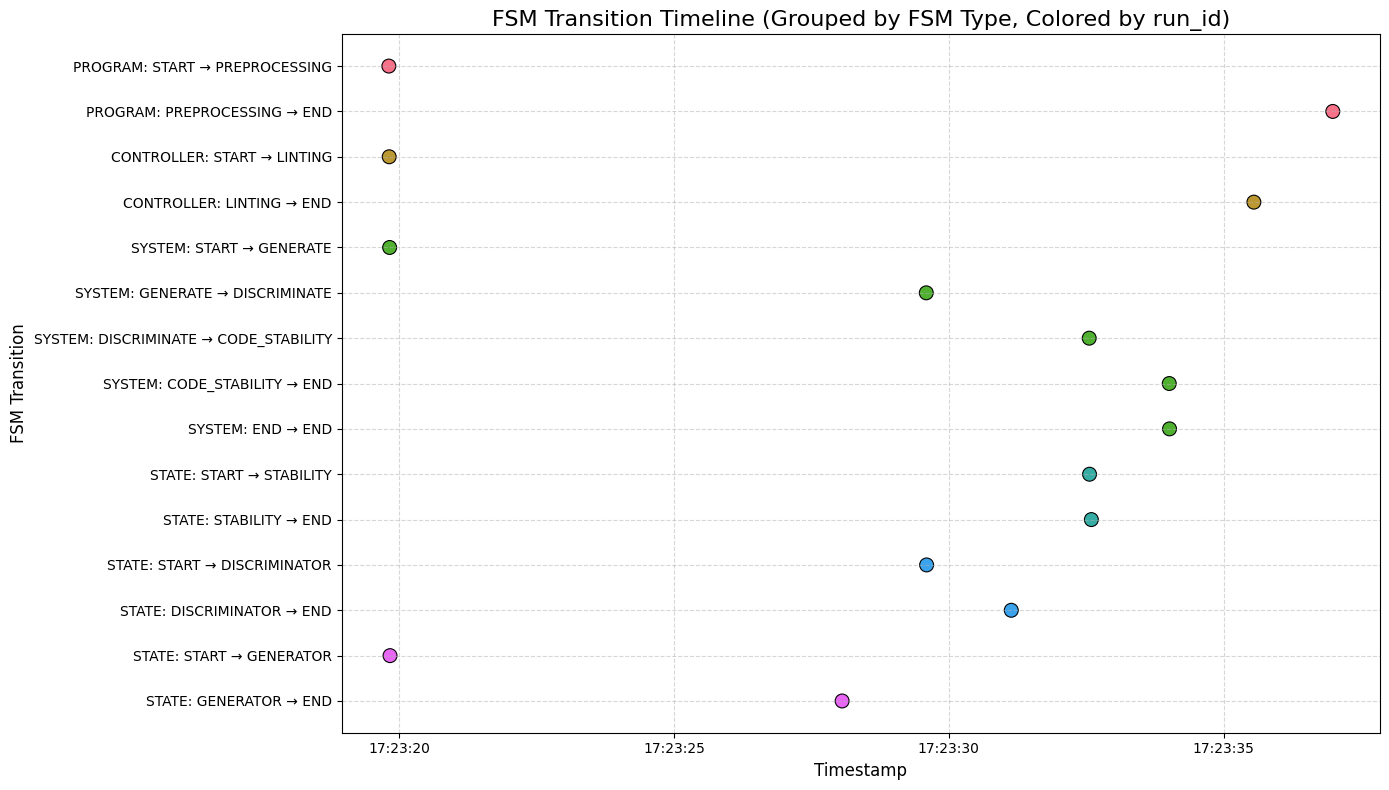

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df_timeline = df.copy()

fsm_order = ["PROGRAM", "CONTROLLER", "SYSTEM", "STATE"]
df_timeline['entity_layer'] = df_timeline['entity_type'].str.split('.').str[-1]
df_timeline['entity_order'] = df_timeline['entity_layer'].apply(lambda x: fsm_order.index(x) if x in fsm_order else 999)

df_timeline = df_timeline.sort_values(by=['entity_order', 'run_id', 'timestamp']).reset_index(drop=True)

df_timeline['label'] = df_timeline.apply(
    lambda row: f"{row['entity_layer']}: {row['from_state'].split('.')[-1]} → {row['to_state'].split('.')[-1]}", axis=1
)

unique_runs = df_timeline['run_id'].unique()
palette = sns.color_palette("husl", len(unique_runs))
run_color_map = dict(zip(unique_runs, palette))
df_timeline['color'] = df_timeline['run_id'].map(run_color_map)

plt.figure(figsize=(14, 8))
sns.scatterplot(
    x='timestamp',
    y='label',
    data=df_timeline,
    hue='run_id',
    palette=run_color_map,
    s=100,
    edgecolor='black',
    legend=False
)

plt.title("FSM Transition Timeline (Grouped by FSM Type, Colored by run_id)", fontsize=16)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("FSM Transition", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 🗂️ File State Transition Lineage (Graphviz)

This code generates a **manual-layout node graph** using **Graphviz** to illustrate the **linear flow of state transitions** across the FSM lifecycle. Each state is visualized as a colored node, positioned in a fixed 4-column grid layout for clarity.

#### 🧠 What this code does:

* **Prepares the data**:

  * Extracts structured transition metadata (including file names) from the `transition_metadata` field.
  * Computes a color for each node based on its `entity_type` (e.g., `CONTROLLER`, `STATE`, `AGENT`).

* **Constructs the graph layout**:

  * Each node corresponds to a `to_state`, visually labeled with:

    * The FSM state name (e.g., `PREPROCESSING`, `LINTING`)
    * The associated filename (e.g., `__ctrl_...py`)
  * Node layout is positioned manually in a fixed grid (4 nodes per row) using the `neato` engine and explicit `(x, y)` coordinates.

* **Adds edges**:

  * Solid arrows represent sequential transitions with labeled metadata (e.g., `ACCEPTED | AGENT`).
  * Dashed arrows mark transitions between rows to preserve visual flow (e.g., "next ➜").

* **Applies styling**:

  * Background colors are applied per provider type (e.g., AGENT = pink, SYSTEM = yellow).
  * Node labels use HTML-style formatting for bold titles and compact file references.
  * The graph includes a left-aligned title with padding (`"File State Transition Lineage"`).

#### 🔍 What you're observing:

* A **horizontally stacked graph** of state transitions across a single FSM session, broken into rows of 4 for visual clarity.
* Each node reflects a meaningful system state, showing which files and providers contributed to the transformation.
* Edge annotations provide context for **who made the decision** and **what the outcome was**, allowing for intuitive tracing of the FSM path.
* Dashed connectors help guide the reader from one row of transitions to the next, forming a readable top-down process view.

This visualization is best suited for **single-run analysis** and **step-by-step traceability** — especially when debugging long or deeply nested transition sequences.


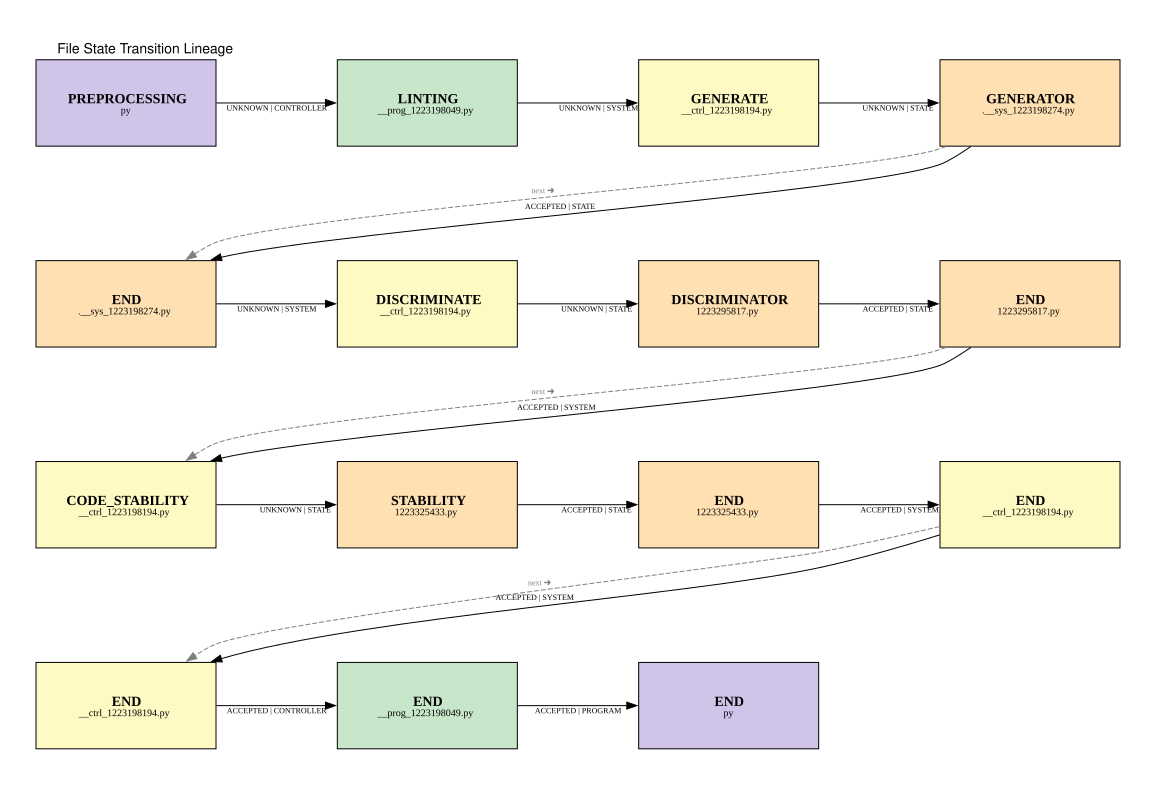

In [5]:
import graphviz
import json

df_vis3 = df.copy()

def parse_metadata(meta):
    if isinstance(meta, dict):
        return meta
    try:
        return json.loads(meta)
    except:
        return {}

df_vis3["parsed_metadata"] = df_vis3["transition_metadata"].apply(parse_metadata)

provider_colors = {
    "SESSION": "#E0F7FA", "PROGRAM": "#D1C4E9", "CONTROLLER": "#C8E6C9",
    "SYSTEM": "#FFF9C4", "STATE": "#FFE0B2", "AGENT": "#FFCDD2", "UNKNOWN": "#E0E0E0"
}

def get_node_props(row):
    meta = row.parsed_metadata
    file = meta.get("original_file", f"unknown_{row.id}")
    file_suffix = file.split("\\")[-1].replace("complex_lint_task.", "").replace("temp_state_", "")
    provider_type = row.entity_type.split(".")[-1] if row.entity_type else "UNKNOWN"
    state_name = row.to_state.split('.')[-1]

    label = f"<<b>{state_name}</b><br/><font point-size='10'>{file_suffix}</font>>"
    color = provider_colors.get(provider_type, "#E0E0E0")
    return label, color

dot = graphviz.Digraph(engine="neato", format="png")

# Correctly adding padding below the title
dot.attr(
    fontsize="14",
    fontname="Helvetica",
    labelloc="t",
    labeljust="l",
    label="    File State Transition Lineage",
    pad="0.5,0.5"
)

nodes = list(df_vis3.itertuples(index=False))
x_spacing, y_spacing = 6.0, -4.0

positions = {}
for idx, row in enumerate(nodes):
    row_num, col_num = divmod(idx, 4)
    x, y = col_num * x_spacing, row_num * y_spacing
    pos = f"{x},{y}!"
    positions[str(row.id)] = (x, y)
    label, color = get_node_props(row)
    dot.node(str(row.id), label=label, fillcolor=color, style="filled", shape="box",
             pos=pos, width="2.5", height="1.2")

for idx in range(len(nodes)-1):
    src, tgt = str(nodes[idx].id), str(nodes[idx+1].id)
    provider = nodes[idx+1].entity_type.split(".")[-1]
    decision = nodes[idx+1].decision.split(".")[-1]
    edge_label = f"{decision} | {provider}"
    dot.edge(src, tgt, label=edge_label, fontsize="8")

for idx in range(3, len(nodes)-1, 4):
    src, tgt = str(nodes[idx].id), str(nodes[idx+1].id)
    dot.edge(src, tgt, style="dashed", color="gray", label="next ➜", fontcolor="gray",
             fontsize="8", constraint="false")

dot.graph_attr.update(overlap="false", splines="true")

from IPython.display import display
display(dot)


### 🔢 State Transition Frequency Matrix

This code generates a **heatmap** to visualize the frequency of transitions between FSM states, using a cross-tabulated matrix of `from_state` → `to_state` transitions.

#### 🧠 What this code does:

* **Prepares the data**:

  * Uses `groupby` and `unstack` to build a **2D matrix** of transition counts between states, where rows are `from_state` and columns are `to_state`.
  * Missing transitions are filled with 0 for clarity.

* **Creates a heatmap**:

  * Uses `seaborn.heatmap` to visualize the matrix with:

    * Cell annotations (`annot=True`) showing the exact count.
    * A **`PuBuGn`** color palette for smooth, visually appealing gradients.
    * Gridlines and light styling to improve readability.

* **Enhances visual formatting**:

  * Axis labels are rotated and resized for clarity.
  * A color bar (`cbar_kws`) provides a visual key for interpreting transition volume.
  * Spacing and padding are adjusted for professional appearance.

#### 🔍 What you're observing:

* A **heatmap** showing how often each FSM state transitions to another.
* The **x-axis** represents destination states (`to_state`), while the **y-axis** represents source states (`from_state`).
* Darker or more saturated cells indicate **higher frequency transitions**.
* This matrix helps identify:

  * **Dominant paths** through the FSM
  * **Rare or unexpected transitions**
  * Potential **bottlenecks or dead ends** in execution flow

This visualization is ideal for **summarizing system-wide behavior**, especially when analyzing multiple FSM runs or diagnosing state machine complexity.


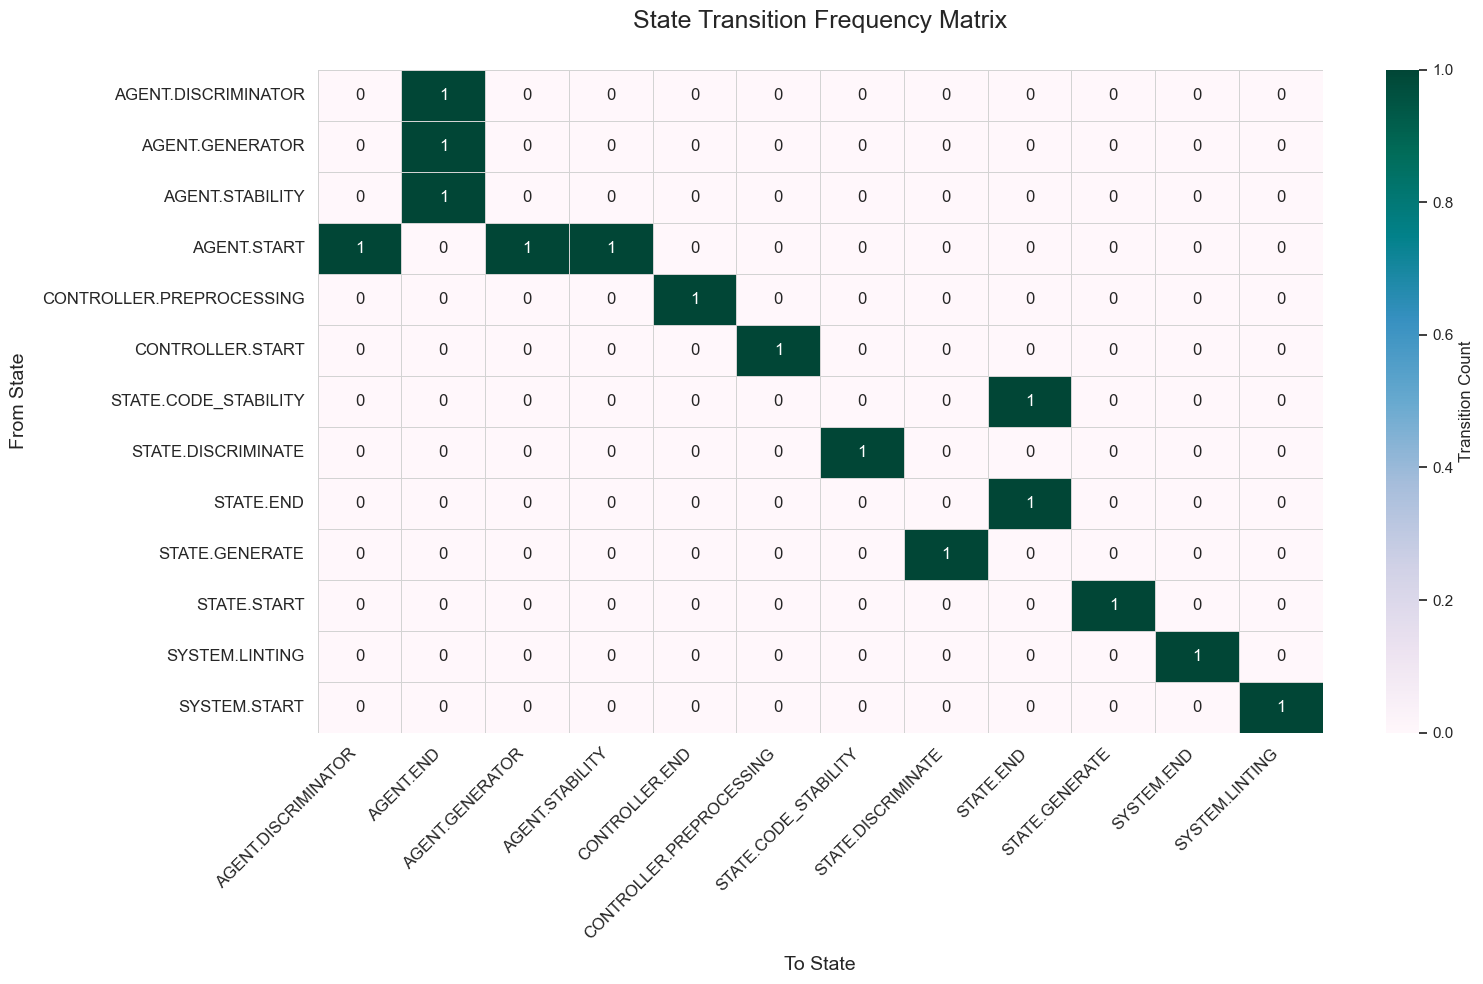

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df_vis1 = df.copy()

# Build transition frequency matrix
transition_counts = (
    df_vis1
    .groupby(['from_state', 'to_state'])
    .size()
    .unstack(fill_value=0)
)

# Set theme
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(16, 10))
ax = sns.heatmap(
    transition_counts,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    linewidths=0.5,
    linecolor='lightgray',
    cbar_kws={"label": "Transition Count"}
)

# Improve label formatting
plt.title("State Transition Frequency Matrix", fontsize=18, loc="center", pad=30)
plt.xlabel("To State", fontsize=14, labelpad=10)
plt.ylabel("From State", fontsize=14, labelpad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

# Light grid behind heatmap cells
ax.grid(False)
plt.tight_layout()
plt.show()



### 📊 Transition Reason Distribution

This code generates a **countplot** to visualize the distribution of **transition reasons** across the FSM state transitions.

#### 🧠 What this code does:

* **Prepares the data**: The `reason_label` column is created by splitting the `reason` field, showing only the part of the reason after the last period (`.`), making the labels more readable (e.g., `SUCCESSFUL` instead of `TRANSITION_REASON_TYPE.SUCCESSFUL`).

* **Creates a countplot**:

  * The `x-axis` shows **transition reasons**, and the `y-axis` shows the **count of occurrences** for each reason.
  * **Color-coded** by reason, where each reason has its own distinct color to aid in visual differentiation.

#### 🔍 What you're observing:

* A **countplot** showing the **distribution of transition reasons** across all recorded FSM transitions.
* The **x-axis** labels represent different types of reasons for state transitions (such as `INITIALIZATION`, `SUCCESSFUL`, `EVALUATING`, etc.).
* The **y-axis** shows how often each reason occurs in the data, providing insight into the frequency of different transition types.

This visualization helps you quickly assess the **most common reasons** for transitions and identify potential patterns or anomalies in the state machine's operation.

In [7]:
import plotly.express as px

# Step 1: Copy and clean
df_reasons = df.copy()
df_reasons["reason_label"] = df_reasons["reason"].apply(lambda x: x.split(".")[-1] if isinstance(x, str) else "Unknown")

# Step 2: Count transition reasons
reason_counts = (
    df_reasons["reason_label"]
    .value_counts()
    .rename_axis("reason_label")
    .reset_index(name="reason_count")
    .sort_values("reason_count", ascending=False)
)

# Step 3: Plot
fig = px.bar(
    reason_counts,
    x="reason_label",
    y="reason_count",
    text="reason_count",
    title="🔄 Transition Reason Distribution",
    labels={"reason_label": "Transition Reason", "reason_count": "Count"},
    color="reason_label",
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textposition="outside")

fig.update_layout(
    height=600,
    xaxis_title="Transition Reason",
    yaxis_title="Count",
    margin=dict(l=50, r=50, t=50, b=100),
    showlegend=False
)

fig.show()


### 📊 Steps per FSM Type

This code generates a **bar chart** showing the **maximum number of steps** taken by each **FSM entity type** (Program, Controller, System, State).

#### 🧠 What this code does:

* **Counts steps**: Uses `cumcount()` to count steps per entity type, ensuring transitions are tracked correctly.

* **Groups by entity type**: Groups the data by `entity_type` and counts the **maximum number of steps** for each FSM type.

* **Label Formatting**: Modifies the x-axis labels to show only the part of the **entity type** after the final period (`.`), so the label is cleaner (e.g., `PROGRAM`, `CONTROLLER` instead of `PROVIDER_TYPE.PROGRAM`).

* **Plotting**:

  * Creates a **bar chart** where the height of each bar represents the number of steps for each FSM type.
  * The **x-axis** shows the FSM types (Program, Controller, System, State), and the **y-axis** shows the **step counts**.

#### 🔍 What you're observing:

* **Bar chart** showing the **step counts** per FSM type.
* The bars reflect the **maximum number of steps** taken by each type during execution, giving insight into how complex or long-running each FSM layer is.
* Helps identify whether certain layers (e.g., **Program** or **Controller**) require more steps for transitions than others.

This chart is a useful tool for **analyzing FSM complexity**, identifying bottlenecks, and understanding which parts of the system involve more transitions or processing steps.

In [8]:
import plotly.express as px

# Copy to avoid modifying original
df_steps = df.copy()

# Count steps per FSM entity type
df_steps['step_count'] = df_steps.groupby('entity_type').cumcount() + 1
steps_per_type = df_steps.groupby('entity_type')['step_count'].max().reset_index()

# Clean the entity_type to just the final label
steps_per_type['fsm_type'] = steps_per_type['entity_type'].str.split('.').str[-1]

# Sort for visual clarity
steps_per_type = steps_per_type.sort_values('step_count', ascending=False)

# Plot
fig = px.bar(
    steps_per_type,
    x='fsm_type',
    y='step_count',
    text='step_count',
    title="📊 Steps per FSM Type",
    labels={"fsm_type": "FSM Type", "step_count": "Total Steps"},
    color="fsm_type",
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_traces(textposition="outside")

fig.update_layout(
    height=600,
    xaxis_title="FSM Type",
    yaxis_title="Total Steps",
    margin=dict(l=50, r=50, t=50, b=80),
    showlegend=False
)

fig.show()
